# Week 1.1 - AI-assisted scientific software

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week01_1/W1_1_AI_Assisted_Scientific_Software.ipynb)

<!-- MIE690A article-aligned validation v4 -->

**Research question.** Can a velocity-field diagnostic proposed by a
person or coding agent be accepted using evidence fixed before the final
CFD result is inspected?

This notebook is intentionally vendor-neutral and makes no remote model
call. It audits the executable contract in `SCIENTIFIC_SPEC.md` through
analytic verification, a real accepted cavity field, physical gates,
and content-addressed provenance.

**Learning outcomes**

1. distinguish execution, verification, validation, and reproducibility;
2. expose array-axis and sign conventions as testable requirements;
3. predeclare thresholds and retain failures; and
4. state which decisions remain the investigator's responsibility.

In [1]:
from pathlib import Path
import os, subprocess, sys

# FLOWMLLAB_COLAB_BOOTSTRAP_V1

def find_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "flowmllab" / "scientific_software.py").is_file():
            return candidate
    return None

ROOT = find_root()
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if ROOT is None and IN_COLAB:
    ROOT = Path("/content/FlowMLLab")
    if not ROOT.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(ROOT)],
            check=True,
        )
if ROOT is None:
    raise FileNotFoundError("Run inside a complete FlowMLLab checkout")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("FlowMLLab checkout located; scientific module import enabled")

FlowMLLab checkout located; scientific module import enabled


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from flowmllab.scientific_software import (
    DEFAULT_THRESHOLDS,
    audit_cavity_case,
    differential_diagnostics,
    evaluate_acceptance,
    load_cavity_case,
    manufactured_incompressible_field,
    verification_sweep,
)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

## 1. Freeze the contract before looking at the final case

We define $u[j,i]=u(y_j,x_i)$ and

$$\nabla\cdot\mathbf{u}=\partial_xu+\partial_yv,\qquad
\omega_z=\partial_xv-\partial_yu.$$

A correct implementation must therefore encode both the array axes and
the vorticity sign. The limits below are part of the experiment, not
plotting preferences.

In [3]:
pd.DataFrame(
    {"gate": list(DEFAULT_THRESHOLDS), "frozen threshold": list(DEFAULT_THRESHOLDS.values())}
)

,gate,frozen threshold
0,observed_order_min,1.900000e+00
1,fine_vorticity_relative_l2_max,5.000000e-04
2,manufactured_divergence_rms_max,1.000000e-12
3,cavity_divergence_rms_max,1.000000e-12
4,cavity_vorticity_relative_l2_max,4.000000e-02
5,wall_velocity_max_abs_error_max,1.000000e-12


## 2. Verify against a known solution

Use $\psi=\sin^2(\pi x)\sin^2(\pi y)$,
$u=\partial_y\psi$, and $v=-\partial_x\psi$. This field has exact zero
divergence, vanishes at every wall, and has an analytic vorticity. Four
grids test convergence; a single fine grid cannot establish order.

In [4]:
verification = verification_sweep((17, 33, 65, 129))
verification_table = pd.DataFrame(verification["rows"])
display(verification_table)
print(f"Observed vorticity order p = {verification['observed_order']:.4f}")

,points,h,vorticity_relative_l2,divergence_rms
0,17,0.062500,0.025505,3.058563e-15
1,33,0.031250,0.006413,6.953772e-15
2,65,0.015625,0.001606,1.481043e-14
3,129,0.007812,0.000402,2.748431e-14


Observed vorticity order p = 1.9965


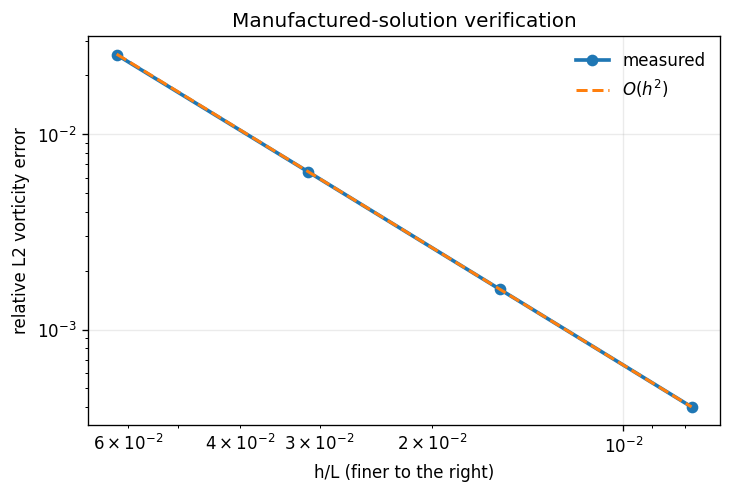

In [5]:
h = verification_table["h"].to_numpy()
error = verification_table["vorticity_relative_l2"].to_numpy()
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.loglog(h, error, "o-", lw=2.2, label="measured")
ax.loglog(h, error[-1] * (h / h[-1])**2, "--", lw=1.8, label=r"$O(h^2)$")
ax.invert_xaxis(); ax.set_xlabel("h/L (finer to the right)")
ax.set_ylabel("relative L2 vorticity error"); ax.legend(frameon=False)
ax.set_title("Manufactured-solution verification")
plt.show()

## 3. A plausible axis bug must fail

The next expression executes and returns an array of the expected shape,
yet differentiates with respect to the wrong coordinate directions. A
shape test alone cannot detect it.

In [6]:
x, y, u, v, omega_exact = manufactured_incompressible_field(129)
omega_axis_swapped = (
    np.gradient(v, y, axis=0, edge_order=2)
    - np.gradient(u, x, axis=1, edge_order=2)
)
interior = np.s_[2:-2, 2:-2]
faulty_relative_l2 = np.linalg.norm((omega_axis_swapped-omega_exact)[interior]) / np.linalg.norm(omega_exact[interior])
print(f"Axis-swapped relative L2 = {faulty_relative_l2:.3f}")
print("Gate:", "PASS" if faulty_relative_l2 <= DEFAULT_THRESHOLDS["fine_vorticity_relative_l2_max"] else "FAIL (expected)")

Axis-swapped relative L2 = 1.232
Gate: FAIL (expected)


## 4. Open the real CFD case only after verification

The `Re=100` case is an accepted 65 by 65 lid-driven-cavity field from
the fixed Week-1 archive. We preserve its split label and SHA-256 digest,
exclude two outer stencil layers from derivative comparisons, and test
the walls separately. Agreement with archived vorticity is not expected
to be exact because the stored solver quantity and this post-processing
stencil differ near boundaries.

In [7]:
cavity = audit_cavity_case(ROOT, 100.0)
display(pd.DataFrame([cavity]).T.rename(columns={0: "value"}))

,value
reynolds,100.0
split,train
grid,"[65, 65]"
dataset_sha256,09b96b744ee4d18126d8dcc92feb60e128774a1b4d41bb...
interior_divergence_rms,0.0
interior_divergence_linf,0.0
archive_vorticity_relative_l2,0.029021
wall_velocity_max_abs_error,0.0


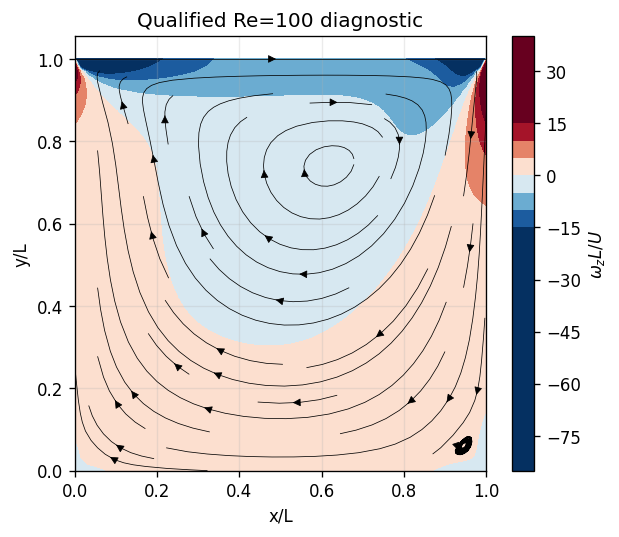

In [8]:
case, _ = load_cavity_case(ROOT, 100.0)
diagnostic = differential_diagnostics(case["x"], case["y"], case["u"], case["v"])
fig, ax = plt.subplots(figsize=(5.6, 4.7))
lim = np.percentile(np.abs(diagnostic.vorticity), 98.5)
cf = ax.contourf(case["x"], case["y"], diagnostic.vorticity, 25, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.streamplot(case["x"], case["y"], case["u"], case["v"], color="k", density=.65, linewidth=.45)
ax.set_aspect("equal"); ax.set_xlabel("x/L"); ax.set_ylabel("y/L")
ax.set_title("Qualified Re=100 diagnostic"); fig.colorbar(cf, ax=ax, label=r"$\omega_zL/U$")
plt.show()

## 5. Make one machine-readable decision

Every failed gate remains visible. The final Boolean does not replace the
underlying values, thresholds, dataset identity, or scientific review.

In [9]:
record = evaluate_acceptance(verification, cavity)
gate_table = pd.DataFrame(
    [{"gate": gate, "passed": passed} for gate, passed in record["gates"].items()]
)
display(gate_table)
print("FINAL DECISION:", record["decision"].upper())
from flowmllab.scientific_software import validate_week01_1_evidence
# Metric roundoff is allowed; data hashes, thresholds and decisions stay exact.
retained = validate_week01_1_evidence(ROOT)

,gate,passed
0,dataset_identity,True
1,second_order_verification,True
2,fine_grid_vorticity,True
3,manufactured_incompressibility,True
4,cavity_incompressibility,True
5,cavity_vorticity_agreement,True
6,cavity_wall_contract,True


FINAL DECISION: ACCEPT


## 6. Required AI-use disclosure and manual review

The assessed assignment requires a coding agent of your choice.
Complete [PROCESS_LOG.md](PROCESS_LOG.md) with actual interaction records:

- **Tool/model/date:**
- **Exact specification supplied:**
- **Functions or files proposed by the tool:**
- **Material human corrections and physical reason:**
- **Independent commands executed:**
- **Failed gates retained:**
- **Bounded claim:**

Review every changed code and test line using [LINE_REVIEW.md](LINE_REVIEW.md).
Cover axis order, units, signs, quadrature, boundaries, invalid inputs and
reference independence. Record actual human corrections; never fabricate them.

## 7. Required GitHub implementation assignment

Follow [ASSIGNMENT.md](ASSIGNMENT.md). First complete and commit [SPEC.md](SPEC.md),
then ask a coding agent to add `net_volume_flux(x, y, u, v)` in
`flowmllab/student_mass_balance.py`. The function is your new contribution;
running the instructor's reference notebook is only preparation.

Run `python qa/check_week01_1_candidate.py flowmllab/student_mass_balance.py`
from the repository root, then the existing scientific-software tests.
Report unit, numerical-regression, physical-invariant and independent-reference
evidence separately. Preserve failed attempts and the original AI patch.
Submit the diff, specification-first commit, process log, line review and
[REPORT.md](REPORT.md), titled **What the agent produced, what the physicist
corrected, and why**, as a PR in your own fork or the instructor-designated repo.

**Exit question:** Which passing gate would still be insufficient for an
unstructured-mesh turbulent-flow claim, and what new reference would you
require?